## Assignment 1
by Darsh Jain
25B4812

all_teacher.csv, unique_people_dataset_2000.csv and rocket_fuel_data.csv to be kept in same folder as this file before running the codes.


### Q.1 Finding the Killer


In [3]:
import pandas as pd

# I only check for teachers as the best friend is likely a colleague at school
df = pd.read_csv("all_teacher.csv")

# Assumptions
df = df[(df['age']>=30) & (df['age']<=45)]
df = df[(df['height']>=160) & (df['height']<=190)]
df = df[(df['weight']>=50)&(df['weight']<=100)]

# Since they were close friends, the colleague must have joined school either before or with the victim
df = df[df['Joining year']<=2014]

# All teachers were home at 10pm which makes only a teacher from city east or city south to possibly be a killer
df = df[(df['location']=='city_east') | (df['location']=='city_south')].reset_index(drop=True)

print("After, carefully going through all the clues, We are left with",len(df),"suspects.")

print("The killer is ",end="")
for i in range(len(df)):
    print(df.loc[i,'name'])

After, carefully going through all the clues, We are left with 1 suspects.
The killer is Jhon Williams


### Q2. Rocket Fuel data analysis

In [4]:
# Step 1 - Exploring data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("rocket_fuel_data.csv")

print(df.head())
print(df.shape)
print(df.describe())

      Fuel_Type  Temperature_C  Pressure_atm  Thrust_kN  Efficiency_Percent  \
0      HydroX-9         3200.0          85.4     1450.0                88.5   
1  NebulaFuel-3         2800.0           NaN     1200.0                76.2   
2  PlasmaCore-7         4100.0         120.3     2100.0                92.1   
3   CryoBlast-2         1900.0          60.1      850.0                65.4   
4      HydroX-9         3500.0          95.2     1680.0                90.3   

  Reactor_Stability  Oxygen_Level_Percent Target_Planet  
0            Stable                  21.3          Mars  
1          Unstable                  19.8         Venus  
2            Stable                  22.7       Jupiter  
3            Stable                  20.1          Moon  
4            Stable                   NaN          Mars  
(40, 8)
       Temperature_C  Pressure_atm    Thrust_kN  Efficiency_Percent  \
count      38.000000      35.00000    39.000000           40.000000   
mean     3256.578947      9

In [5]:
# Step 2 - replacing missing values with mean

tm = df['Temperature_C'].mean()
pm = df['Pressure_atm'].mean()
thm = df["Thrust_kN"].mean()
om = df['Oxygen_Level_Percent'].mean()

df = df.fillna({'Temperature_C':tm,'Pressure_atm':pm,'Thrust_kN':thm,'Oxygen_Level_Percent':om})

df

,Fuel_Type,Temperature_C,Pressure_atm,Thrust_kN,Efficiency_Percent,Reactor_Stability,Oxygen_Level_Percent,Target_Planet
0,HydroX-9,3200.000000,85.4,1450.000000,88.5,Stable,21.300000,Mars
1,NebulaFuel-3,2800.000000,94.7,1200.000000,76.2,Unstable,19.800000,Venus
2,PlasmaCore-7,4100.000000,120.3,2100.000000,92.1,Stable,22.700000,Jupiter
3,CryoBlast-2,1900.000000,60.1,850.000000,65.4,Stable,20.100000,Moon
4,HydroX-9,3500.000000,95.2,1680.000000,90.3,Stable,21.662162,Mars
5,NebulaFuel-3,2600.000000,72.8,980.000000,71.5,Unstable,18.900000,Venus
6,TitanFlare-5,3800.000000,110.5,1920.000000,85.7,Stable,23.100000,Saturn
7,CryoBlast-2,2100.000000,65.3,920.000000,68.2,Stable,20.500000,Moon
8,PlasmaCore-7,4300.000000,94.7,2350.000000,94.6,Stable,24.000000,Jupiter
9,HydroX-9,3100.000000,82.7,1380.000000,86.2,Stable,21.000000,Mars


In [6]:
# Step 3 - Filtering data

print("Experiments with Thrust > 1000")
print(df[df['Thrust_kN']>1000])

print("\n\nUnstable Experiments")
print(df[df['Reactor_Stability']=="Unstable"])

print("\n\nMars Missions")
print(df[df['Target_Planet']=="Mars"])

print("\n\nEfficiency_Percent>80%")
print(df[df['Efficiency_Percent']>80])

Experiments with Thrust > 1000
       Fuel_Type  Temperature_C  Pressure_atm    Thrust_kN  \
0       HydroX-9    3200.000000          85.4  1450.000000   
1   NebulaFuel-3    2800.000000          94.7  1200.000000   
2   PlasmaCore-7    4100.000000         120.3  2100.000000   
4       HydroX-9    3500.000000          95.2  1680.000000   
6   TitanFlare-5    3800.000000         110.5  1920.000000   
8   PlasmaCore-7    4300.000000          94.7  2350.000000   
9       HydroX-9    3100.000000          82.7  1380.000000   
10  NebulaFuel-3    2900.000000          78.4  1100.000000   
11  TitanFlare-5    3256.578947         115.2  2050.000000   
13  PlasmaCore-7    4500.000000         135.7  2600.000000   
14      HydroX-9    3300.000000          88.1  1520.000000   
15  NebulaFuel-3    2700.000000          75.6  1050.000000   
16  TitanFlare-5    3900.000000         118.3  2150.000000   
18  PlasmaCore-7    4200.000000         128.4  2420.000000   
19      HydroX-9    3400.000000        

In [7]:
print(df.sort_values(by="Temperature_C"))
print()
print(df.sort_values(by="Efficiency_Percent", ascending=False))

       Fuel_Type  Temperature_C  Pressure_atm    Thrust_kN  \
12   CryoBlast-2    1800.000000          58.6   790.000000   
3    CryoBlast-2    1900.000000          60.1   850.000000   
37   CryoBlast-2    1950.000000          61.0   810.000000   
27   CryoBlast-2    2000.000000          63.7   830.000000   
7    CryoBlast-2    2100.000000          65.3   920.000000   
32   CryoBlast-2    2150.000000          66.5   910.000000   
17   CryoBlast-2    2200.000000          68.9   960.000000   
20  NebulaFuel-3    2500.000000          70.2   900.000000   
5   NebulaFuel-3    2600.000000          72.8   980.000000   
30  NebulaFuel-3    2650.000000          94.7  1020.000000   
15  NebulaFuel-3    2700.000000          75.6  1050.000000   
1   NebulaFuel-3    2800.000000          94.7  1200.000000   
35  NebulaFuel-3    2850.000000          94.7  1080.000000   
10  NebulaFuel-3    2900.000000          78.4  1100.000000   
25  NebulaFuel-3    3000.000000          80.1  1150.000000   
29      

In [8]:
# Task 5 - New column

df['Power_Index'] = df["Thrust_kN"]*df['Efficiency_Percent']
df

,Fuel_Type,Temperature_C,Pressure_atm,Thrust_kN,Efficiency_Percent,Reactor_Stability,Oxygen_Level_Percent,Target_Planet,Power_Index
0,HydroX-9,3200.000000,85.4,1450.000000,88.5,Stable,21.300000,Mars,128325.000000
1,NebulaFuel-3,2800.000000,94.7,1200.000000,76.2,Unstable,19.800000,Venus,91440.000000
2,PlasmaCore-7,4100.000000,120.3,2100.000000,92.1,Stable,22.700000,Jupiter,193410.000000
3,CryoBlast-2,1900.000000,60.1,850.000000,65.4,Stable,20.100000,Moon,55590.000000
4,HydroX-9,3500.000000,95.2,1680.000000,90.3,Stable,21.662162,Mars,151704.000000
5,NebulaFuel-3,2600.000000,72.8,980.000000,71.5,Unstable,18.900000,Venus,70070.000000
6,TitanFlare-5,3800.000000,110.5,1920.000000,85.7,Stable,23.100000,Saturn,164544.000000
7,CryoBlast-2,2100.000000,65.3,920.000000,68.2,Stable,20.500000,Moon,62744.000000
8,PlasmaCore-7,4300.000000,94.7,2350.000000,94.6,Stable,24.000000,Jupiter,222310.000000
9,HydroX-9,3100.000000,82.7,1380.000000,86.2,Stable,21.000000,Mars,118956.000000


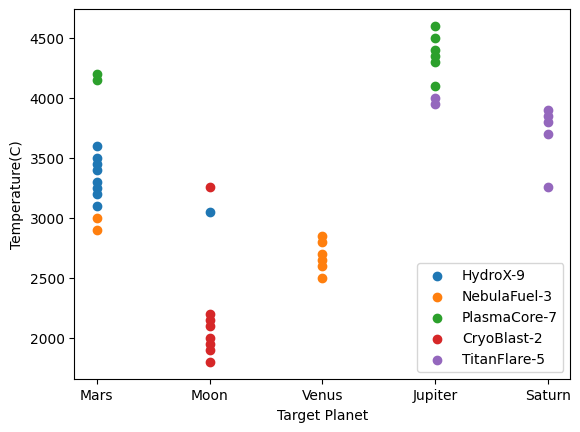

In [9]:
# Task 6 - Plotting all columns

fuels = df["Fuel_Type"].unique()

for f in fuels:
    fuel_data = df[df["Fuel_Type"]==f]

    plt.scatter(fuel_data["Target_Planet"],fuel_data["Temperature_C"],label=f)

plt.xlabel("Target Planet")
plt.ylabel("Temperature(C)")

plt.legend()
plt.show()

<Axes: xlabel='Target_Planet'>

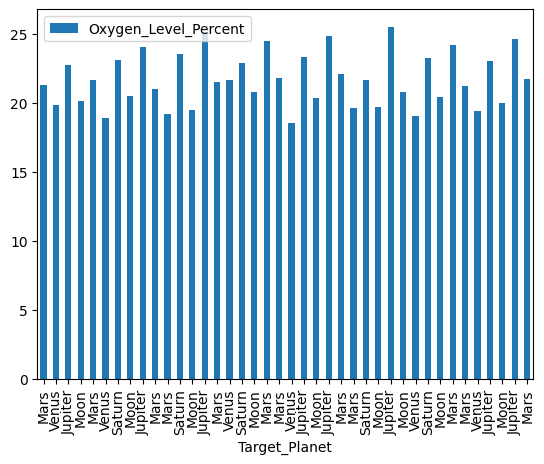

In [10]:
df.plot(x="Target_Planet",y="Oxygen_Level_Percent",kind="bar")

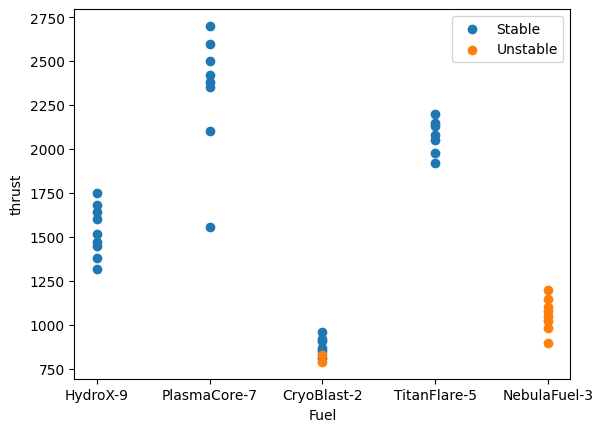

In [11]:
stab = df["Reactor_Stability"].unique()

for s in stab:
    st = df[df["Reactor_Stability"] == s]
    plt.scatter(
        st["Fuel_Type"],
        st["Thrust_kN"],
        label = s
    )

plt.xlabel("Fuel")
plt.ylabel("thrust")

plt.legend()
plt.show()

In [12]:
# task 7 - save new data
df.to_csv("modified.csv")